# Stock Price Prediction — Risk-Adjusted Selling Strategy

**Objective**: Select up to 4,000 stocks (out of 10,000) to sell to maximise:
$$R = \sum_{i} \text{sell}_i \cdot (p40_i - p50_i)$$

We want to sell stocks where `p40 > p50` (price drops), and ideally where the drop is the largest.

**Strategy**: Predict `p50` for each stock using LightGBM regression on engineered features, then rank by a risk-adjusted score and sell the top 4,000.

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

import lightgbm as lgb
import xgboost as xgb

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PRICE_COLS = [f'p{i}' for i in range(1, 41)]  # p1 ... p40
MAX_SELL   = 4000

## Phase 1: Load Data & EDA

In [2]:
train = pd.read_csv('train.csv', index_col='ID')
test  = pd.read_csv('test.csv',  index_col='ID')

print(f'Train: {train.shape}  |  Test: {test.shape}')
train.head(3)

Train: (10000, 41)  |  Test: (10000, 40)


,p1,p2,p3,p4,p5,p6,p7,p8,p9,p10,...,p32,p33,p34,p35,p36,p37,p38,p39,p40,p50
ID,,,,,,,,,,,,,,,,,,,,,
0,95.44,98.63,102.79,99.71,96.48,93.32,88.99,84.61,83.39,82.91,...,90.57,86.88,86.27,83.42,80.25,76.95,73.69,69.15,67.07,56.62
1,104.11,104.35,104.32,104.55,103.28,99.04,96.37,97.07,96.48,92.71,...,65.94,70.90,70.07,69.43,69.45,68.24,68.39,72.00,71.67,52.60
2,109.64,109.58,110.92,108.53,104.98,102.64,107.21,107.96,114.28,111.60,...,117.49,117.19,120.93,122.84,124.58,126.50,130.17,131.77,136.22,125.94


=== (p40 - p50) distribution ===
count    10000.000
mean        -0.043
std         15.177
min        -46.120
25%        -11.343
50%          0.100
75%         11.280
max         41.350
dtype: float64

Stocks where p40 > p50 (natural sell candidates): 5022 / 10000 (50.2%)


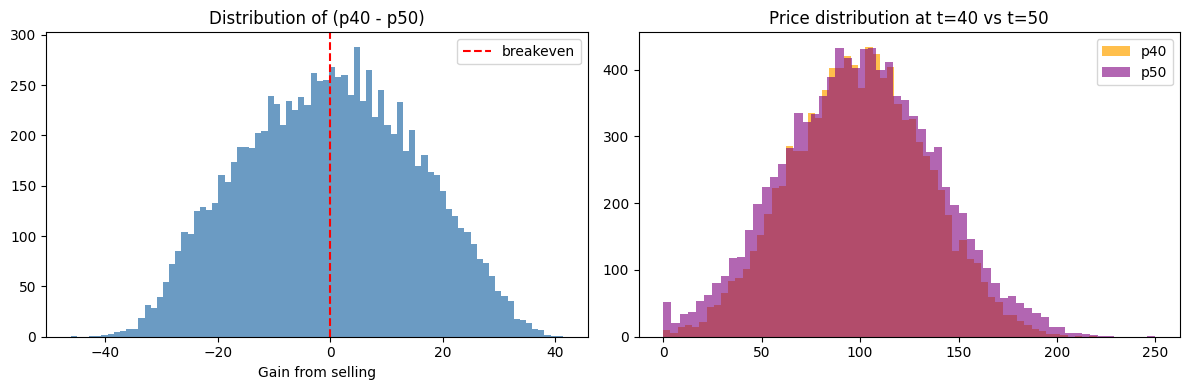

In [3]:
# --- Target analysis ---
gain = train['p40'] - train['p50']           # positive = profitable sell

print('=== (p40 - p50) distribution ===')
print(gain.describe().round(3))
print(f'\nStocks where p40 > p50 (natural sell candidates): {(gain > 0).sum()} / {len(gain)} ({(gain > 0).mean():.1%})')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(gain, bins=80, edgecolor='none', color='steelblue', alpha=0.8)
axes[0].axvline(0, color='red', lw=1.5, ls='--', label='breakeven')
axes[0].set_title('Distribution of (p40 - p50)')
axes[0].set_xlabel('Gain from selling')
axes[0].legend()

axes[1].hist(train['p40'], bins=60, color='orange', alpha=0.7, label='p40')
axes[1].hist(train['p50'], bins=60, color='purple', alpha=0.6, label='p50')
axes[1].set_title('Price distribution at t=40 vs t=50')
axes[1].legend()

plt.tight_layout()
plt.show()

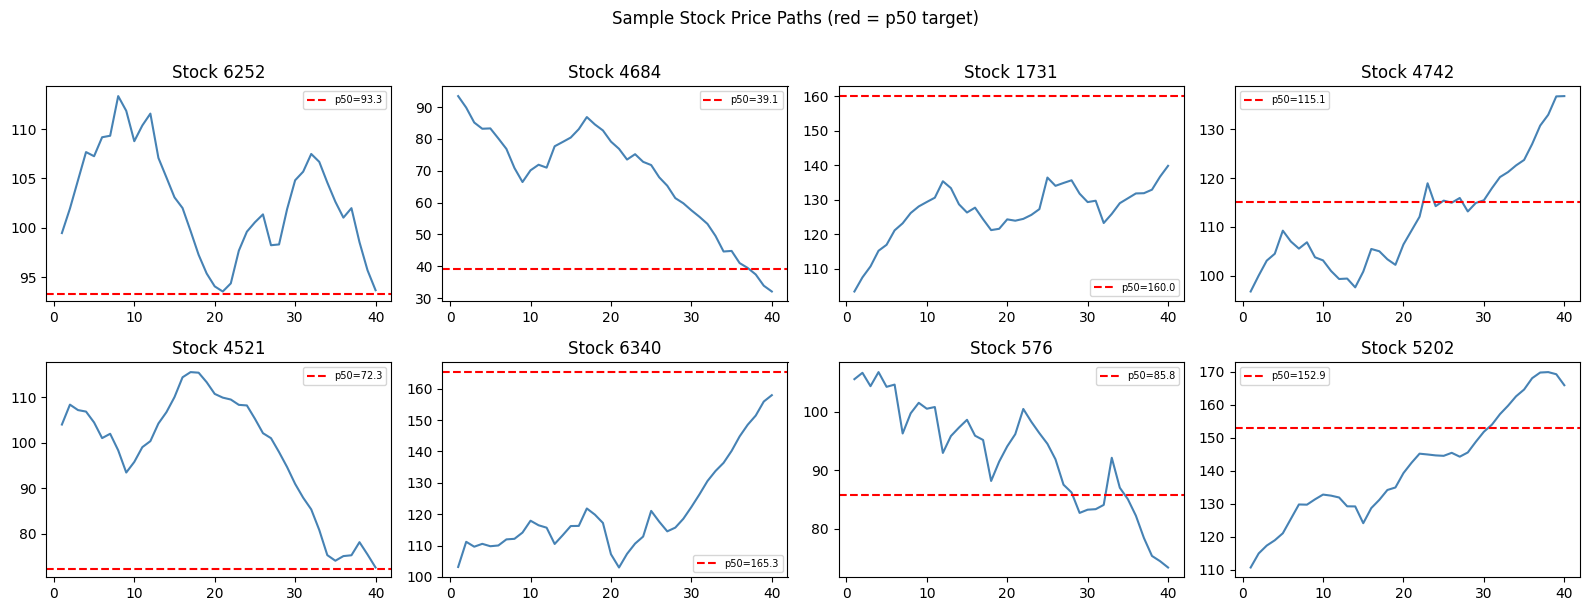

In [4]:
# --- Stationarity check: log-returns remove level effects ---
# Show a few sample price paths
sample_ids = train.sample(8, random_state=RANDOM_STATE).index

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, idx in zip(axes.flat, sample_ids):
    prices = train.loc[idx, PRICE_COLS].values
    ax.plot(range(1, 41), prices, color='steelblue')
    ax.axhline(train.loc[idx, 'p50'], color='red', ls='--', lw=1.5, label=f'p50={train.loc[idx, "p50"]:.1f}')
    ax.set_title(f'Stock {idx}')
    ax.legend(fontsize=7)

plt.suptitle('Sample Stock Price Paths (red = p50 target)', y=1.01)
plt.tight_layout()
plt.show()

## Phase 2: Feature Engineering

We create features from the p1–p40 window capturing:
- **Trend / Momentum**: where is the price heading?
- **Volatility / Risk**: how noisy is the path?
- **Position**: where does p40 sit relative to history?

In [5]:
def compute_rsi(prices: np.ndarray, period: int = 14) -> float:
    """RSI over the last `period` steps of a price array."""
    deltas = np.diff(prices[-period - 1:])
    gain   = np.mean(deltas[deltas > 0]) if np.any(deltas > 0) else 0.0
    loss   = np.mean(-deltas[deltas < 0]) if np.any(deltas < 0) else 0.0
    if loss == 0:
        return 100.0
    rs = gain / loss
    return 100.0 - 100.0 / (1.0 + rs)


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Build a feature matrix from columns p1..p40."""
    # Clip to avoid log(0) = -inf on stocks that hit zero price
    prices_np = np.clip(df[PRICE_COLS].values, 1e-6, None)
    n = len(df)
    feats = {}

    # --- Raw endpoint ---
    feats['p40'] = prices_np[:, -1]
    feats['p1']  = prices_np[:, 0]

    # --- Log-return over full window ---
    feats['log_ret_full'] = np.log(prices_np[:, -1] / prices_np[:, 0])

    # --- Last-step change ---
    feats['last_change']     = prices_np[:, -1] - prices_np[:, -2]
    feats['last_change_pct'] = feats['last_change'] / prices_np[:, -2]

    # --- Momentum: log-returns over sub-windows ---
    for window in [5, 10, 20]:
        feats[f'ret_{window}d'] = np.log(prices_np[:, -1] / prices_np[:, -1 - window])

    # --- Moving averages ---
    feats['ma5']  = prices_np[:, -5:].mean(axis=1)
    feats['ma10'] = prices_np[:, -10:].mean(axis=1)
    feats['ma20'] = prices_np[:, -20:].mean(axis=1)
    feats['ma40'] = prices_np.mean(axis=1)

    # p40 relative to moving averages
    feats['p40_vs_ma5']  = feats['p40'] - feats['ma5']
    feats['p40_vs_ma20'] = feats['p40'] - feats['ma20']
    feats['p40_vs_ma40'] = feats['p40'] - feats['ma40']

    # --- Volatility (price-level) ---
    feats['std10'] = prices_np[:, -10:].std(axis=1)
    feats['std20'] = prices_np[:, -20:].std(axis=1)
    feats['std40'] = prices_np.std(axis=1)

    # log-return volatility (more robust to price level)
    log_rets_all = np.diff(np.log(prices_np), axis=1)   # shape (n, 39)
    feats['vol10'] = log_rets_all[:, -10:].std(axis=1)
    feats['vol20'] = log_rets_all[:, -20:].std(axis=1)
    feats['vol40'] = log_rets_all.std(axis=1)

    # --- Bollinger Band position ---
    upper20    = feats['ma20'] + 2 * feats['std20']
    lower20    = feats['ma20'] - 2 * feats['std20']
    band_width = upper20 - lower20
    feats['bb_pos'] = np.where(
        band_width > 0,
        (feats['p40'] - lower20) / band_width,
        0.5
    )

    # --- Historical context ---
    feats['hist_min']    = prices_np.min(axis=1)
    feats['hist_max']    = prices_np.max(axis=1)
    feats['hist_range']  = feats['hist_max'] - feats['hist_min']
    feats['p40_vs_min']  = feats['p40'] - feats['hist_min']
    feats['p40_vs_max']  = feats['hist_max'] - feats['p40']
    feats['p40_pct_range'] = np.where(
        feats['hist_range'] > 0,
        feats['p40_vs_min'] / feats['hist_range'],
        0.5
    )

    # --- RSI ---
    feats['rsi14'] = np.array([compute_rsi(prices_np[i]) for i in range(n)])

    # --- Trend slope (OLS on log-prices) ---
    t      = np.arange(40)
    t_norm = (t - t.mean()) / t.std()
    log_p  = np.log(prices_np)
    feats['trend_slope'] = (
        (log_p * t_norm).mean(axis=1)
        - log_p.mean(axis=1) * t_norm.mean()
    )

    # --- Momentum acceleration: 2nd half vs 1st half return ---
    feats['ret_2nd_half']   = np.log(prices_np[:, -1]  / prices_np[:, 19])
    feats['ret_1st_half']   = np.log(prices_np[:, 19]  / prices_np[:, 0])
    feats['momentum_accel'] = feats['ret_2nd_half'] - feats['ret_1st_half']

    out = pd.DataFrame(feats, index=df.index)
    # Guard: replace any remaining inf/-inf with NaN, fill with column median
    out.replace([np.inf, -np.inf], np.nan, inplace=True)
    out.fillna(out.median(), inplace=True)
    return out


print('Engineering features for train...')
X_train_feats = engineer_features(train)
print('Engineering features for test...')
X_test_feats  = engineer_features(test)

y_train = train['p50']   # regression target

print(f'\nFeature matrix shape: {X_train_feats.shape}')
print(f'Any NaN: {X_train_feats.isna().any().any()}  Any inf: {np.isinf(X_train_feats.values).any()}')
X_train_feats.head(3)

Engineering features for train...
Engineering features for test...

Feature matrix shape: (10000, 33)
Any NaN: False  Any inf: False


,p40,p1,log_ret_full,last_change,last_change_pct,ret_5d,ret_10d,ret_20d,ma5,ma10,...,hist_max,hist_range,p40_vs_min,p40_vs_max,p40_pct_range,rsi14,trend_slope,ret_2nd_half,ret_1st_half,momentum_accel
ID,,,,,,,,,,,,,,,,,,,,,
0,67.07,95.44,-0.352761,-2.08,-0.030080,-0.218151,-0.237267,-0.319416,73.422,79.888,...,102.79,35.72,0.00,35.72,0.000000,68.554687,-0.047248,-0.319416,-0.033345,-0.286070
1,71.67,104.11,-0.373376,-0.33,-0.004583,0.031753,0.054184,-0.237248,69.950,69.291,...,104.55,38.61,5.73,32.88,0.148407,60.492802,-0.144957,-0.237248,-0.136128,-0.101119
2,136.22,109.64,0.217069,4.45,0.033771,0.103389,0.120797,0.133217,129.848,124.411,...,136.22,33.58,33.58,0.00,1.000000,40.075213,0.051650,0.133217,0.083852,0.049365


## Phase 3: Model Training

We train a **LightGBM regressor** to predict `p50` from the features.
We also try XGBoost and ensemble them.

## Phase 3b: Extended Model Comparison

We benchmark 7 model families to find the best predictor of `p50`.

| Model | Category | Key trait |
|---|---|---|
| LightGBM | Gradient Boosting | Fast, histogram-based |
| XGBoost | Gradient Boosting | Exact splits, widely used |
| **CatBoost** | Gradient Boosting | Ordered boosting, often best single model |
| HistGradBoost | Gradient Boosting | sklearn native, no extra deps |
| ExtraTrees | Random Ensemble | Extremely randomized splits |
| RandomForest | Random Ensemble | Bagging over trees |
| Ridge | Linear | Baseline — no interactions |

In [6]:
# 80/20 split for validation
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_feats, y_train, test_size=0.2, random_state=RANDOM_STATE
)

# Keep track of p40 for the validation set (we need it for scoring)
p40_val = train.loc[X_val.index, 'p40']
p50_val = train.loc[X_val.index, 'p50']

print(f'Train: {X_tr.shape}  Val: {X_val.shape}')

Train: (8000, 33)  Val: (2000, 33)


In [7]:
# --- LightGBM ---
lgbm_params = dict(
    objective      = 'regression',
    metric         = 'rmse',
    learning_rate  = 0.05,
    num_leaves     = 63,
    min_child_samples = 20,
    feature_fraction  = 0.8,
    bagging_fraction  = 0.8,
    bagging_freq      = 5,
    reg_alpha      = 0.1,
    reg_lambda     = 1.0,
    n_estimators   = 1000,
    random_state   = RANDOM_STATE,
    verbose        = -1,
)

lgbm_model = lgb.LGBMRegressor(**lgbm_params)
lgbm_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(200)]
)

lgbm_val_preds = lgbm_model.predict(X_val)
lgbm_rmse = mean_squared_error(y_val, lgbm_val_preds) ** 0.5
lgbm_mae  = mean_absolute_error(y_val, lgbm_val_preds)
print(f'LightGBM  RMSE: {lgbm_rmse:.4f}  MAE: {lgbm_mae:.4f}')

LightGBM  RMSE: 14.5977  MAE: 12.0759


In [8]:
# --- XGBoost ---
xgb_model = xgb.XGBRegressor(
    objective      = 'reg:squarederror',
    learning_rate  = 0.05,
    max_depth      = 5,
    n_estimators   = 1000,
    subsample      = 0.8,
    colsample_bytree = 0.8,
    reg_alpha      = 0.1,
    reg_lambda     = 1.0,
    random_state   = RANDOM_STATE,
    verbosity      = 0,
    early_stopping_rounds = 50,
)

xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=200
)

xgb_val_preds = xgb_model.predict(X_val)
xgb_rmse = mean_squared_error(y_val, xgb_val_preds) ** 0.5
xgb_mae  = mean_absolute_error(y_val, xgb_val_preds)
print(f'XGBoost   RMSE: {xgb_rmse:.4f}  MAE: {xgb_mae:.4f}')

[0]	validation_0-rmse:35.94259
[137]	validation_0-rmse:14.55173
XGBoost   RMSE: 14.5269  MAE: 12.0187


In [9]:
# --- Ensemble: average the two ---
ens_val_preds = 0.5 * lgbm_val_preds + 0.5 * xgb_val_preds
ens_rmse = mean_squared_error(y_val, ens_val_preds) ** 0.5
ens_mae  = mean_absolute_error(y_val, ens_val_preds)
print(f'Ensemble  RMSE: {ens_rmse:.4f}  MAE: {ens_mae:.4f}')

model_comparison = pd.DataFrame({
    'Model': ['LightGBM', 'XGBoost', 'Ensemble (50/50)'],
    'RMSE':  [lgbm_rmse, xgb_rmse, ens_rmse],
    'MAE':   [lgbm_mae,  xgb_mae,  ens_mae],
}).set_index('Model').round(4)

display(model_comparison)

# Pick the best
best_val_preds = ens_val_preds   # use ensemble going forward

Ensemble  RMSE: 14.5257  MAE: 12.0235


,RMSE,MAE
Model,,
LightGBM,14.5977,12.0759
XGBoost,14.5269,12.0187
Ensemble (50/50),14.5257,12.0235


In [ ]:
import time
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from catboost import CatBoostRegressor

PENALTY_GRID = [1.0, 5.0, 10.0, 20.0, 50.0]
p40_v   = p40_val.values
p50_v   = p50_val.values
sigma_v = X_val['std10'].values
K_val   = int(0.4 * len(X_val))

def _best_sells_arr(preds, p40, sigma, penalty, K):
    scores = (p40 - preds) / (sigma + penalty)
    idx = np.argsort(scores)[::-1][:K]
    s = np.zeros(len(preds), dtype=int); s[idx] = 1
    return s

def _competition_R(s, p40_vals, p50_vals, K):
    s = s.copy()
    if s.sum() > K:
        ones = np.where(s == 1)[0]
        keep = np.random.choice(ones, K, replace=False)
        s[:] = 0; s[keep] = 1
    return float((s * (p40_vals - p50_vals)).sum())

def evaluate_model(name, preds_val, fit_time):
    rmse = mean_squared_error(y_val, preds_val) ** 0.5
    mae  = mean_absolute_error(y_val, preds_val)
    best_R, best_pen = -1e9, 10.0
    for pen in PENALTY_GRID:
        s = _best_sells_arr(preds_val, p40_v, sigma_v, pen, K_val)
        r = _competition_R(s, p40_v, p50_v, K_val)
        if r > best_R:
            best_R, best_pen = r, pen
    return {'Model': name, 'RMSE': round(rmse, 4), 'MAE': round(mae, 4),
            'Val R': round(best_R, 1), 'Best Penalty': best_pen, 'Fit time (s)': round(fit_time, 1)}

comparison_rows = [
    evaluate_model('LightGBM',          lgbm_val_preds,  0),
    evaluate_model('XGBoost',           xgb_val_preds,   0),
    evaluate_model('Ensemble LGB+XGB',  ens_val_preds,   0),
]
val_preds_store = {
    'lgbm': lgbm_val_preds,
    'xgb':  xgb_val_preds,
}
print('Existing models registered. Training new models...\n')

In [ ]:
# ── Model 3: CatBoost ─────────────────────────────────────────────────────────
t0 = time.time()
cat_model = CatBoostRegressor(
    iterations         = 1000,
    learning_rate      = 0.05,
    depth              = 6,
    l2_leaf_reg        = 3,
    random_seed        = RANDOM_STATE,
    eval_metric        = 'RMSE',
    early_stopping_rounds = 50,
    verbose            = False,
)
cat_model.fit(X_tr, y_tr, eval_set=(X_val, y_val))
cat_val_preds = cat_model.predict(X_val)
cat_time = time.time() - t0

comparison_rows.append(evaluate_model('CatBoost', cat_val_preds, cat_time))
val_preds_store['cat'] = cat_val_preds
print(f"CatBoost done  best_iter={cat_model.best_iteration_}  time={cat_time:.1f}s")

In [ ]:
# ── Model 4: HistGradientBoosting (sklearn, no extra deps) ────────────────────
t0 = time.time()
hgb_model = HistGradientBoostingRegressor(
    max_iter           = 500,
    learning_rate      = 0.05,
    max_leaf_nodes     = 63,
    min_samples_leaf   = 20,
    l2_regularization  = 1.0,
    random_state       = RANDOM_STATE,
    early_stopping     = True,
    validation_fraction = 0.1,
    n_iter_no_change   = 30,
)
hgb_model.fit(X_tr, y_tr)
hgb_val_preds = hgb_model.predict(X_val)
hgb_time = time.time() - t0

comparison_rows.append(evaluate_model('HistGradBoost (sklearn)', hgb_val_preds, hgb_time))
val_preds_store['hgb'] = hgb_val_preds
print(f"HistGBM done  n_iter={hgb_model.n_iter_}  time={hgb_time:.1f}s")

# ── Model 5: ExtraTrees ───────────────────────────────────────────────────────
t0 = time.time()
et_model = ExtraTreesRegressor(n_estimators=300, min_samples_leaf=5, n_jobs=-1, random_state=RANDOM_STATE)
et_model.fit(X_tr, y_tr)
et_val_preds = et_model.predict(X_val)
et_time = time.time() - t0

comparison_rows.append(evaluate_model('ExtraTrees', et_val_preds, et_time))
val_preds_store['et'] = et_val_preds
print(f"ExtraTrees done  time={et_time:.1f}s")

# ── Model 6: RandomForest ─────────────────────────────────────────────────────
t0 = time.time()
rf_model = RandomForestRegressor(n_estimators=300, min_samples_leaf=5, n_jobs=-1, random_state=RANDOM_STATE)
rf_model.fit(X_tr, y_tr)
rf_val_preds = rf_model.predict(X_val)
rf_time = time.time() - t0

comparison_rows.append(evaluate_model('RandomForest', rf_val_preds, rf_time))
val_preds_store['rf'] = rf_val_preds
print(f"RandomForest done  time={rf_time:.1f}s")

# ── Model 7: Ridge (linear baseline) ──────────────────────────────────────────
t0 = time.time()
ridge_model = Pipeline([('sc', StandardScaler()), ('ridge', Ridge(alpha=10.0))])
ridge_model.fit(X_tr, y_tr)
ridge_val_preds = ridge_model.predict(X_val)
ridge_time = time.time() - t0

comparison_rows.append(evaluate_model('Ridge (linear)', ridge_val_preds, ridge_time))
val_preds_store['ridge'] = ridge_val_preds
print(f"Ridge done  time={ridge_time:.1f}s")

In [ ]:
# ── Grand ensemble: LGBM + XGB + CatBoost + HGB ───────────────────────────────
ens4_val_preds = (lgbm_val_preds + xgb_val_preds + cat_val_preds + hgb_val_preds) / 4
comparison_rows.append(evaluate_model('★ Ensemble (LGBM+XGB+Cat+HGB)', ens4_val_preds, 0))

# ── Summary table ─────────────────────────────────────────────────────────────
comp_df = pd.DataFrame(comparison_rows).set_index('Model').sort_values('Val R', ascending=False)
display(comp_df.style.highlight_max(subset=['Val R'], color='lightgreen')
                     .highlight_min(subset=['RMSE'],  color='lightblue'))

# ── Bar chart: Val R by model ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

comp_df['Val R'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Validation R by Model (higher = better)')
axes[0].set_xlabel('R')

comp_df['RMSE'].sort_values(ascending=False).plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Validation RMSE by Model (lower = better)')
axes[1].set_xlabel('RMSE')

plt.tight_layout()
plt.show()

# Best predictions to carry forward
best_val_preds = ens4_val_preds
print(f'\nBest strategy: {comp_df["Val R"].idxmax()}  →  R = {comp_df["Val R"].max():.1f}')

## Feature Importance

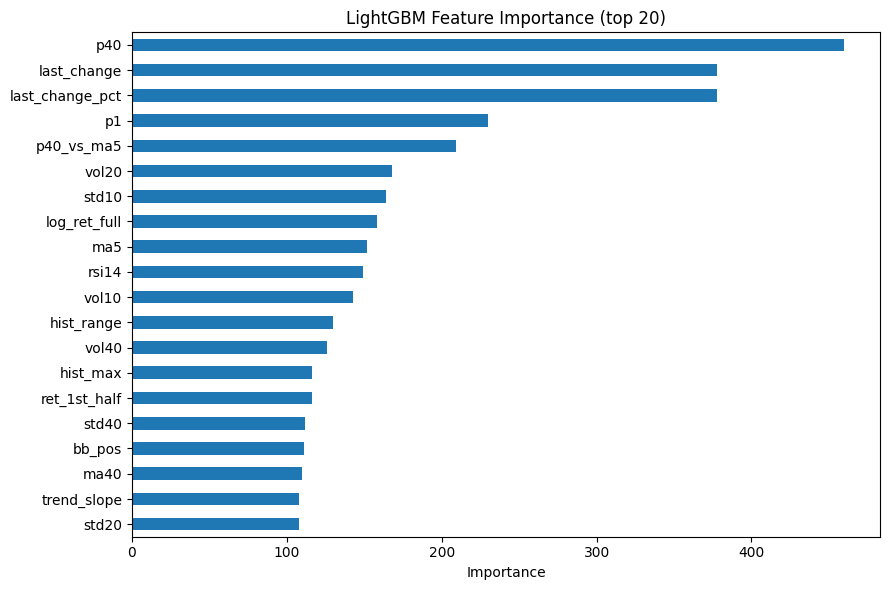

In [10]:
feat_imp = pd.Series(
    lgbm_model.feature_importances_,
    index=X_train_feats.columns
).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
feat_imp.head(20).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('LightGBM Feature Importance (top 20)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## Phase 4: Risk-Adjusted Ranking

For each stock, compute:
$$\text{Expected Gain} = p40 - \hat{p50}$$
$$\text{Score} = \frac{p40 - \hat{p50}}{\sigma + \text{penalty}}$$

where $\sigma$ = rolling 10-day volatility (std of prices).

We then pick the top 4,000 by Score.

In [11]:
RISK_PENALTY = 1.0   # adds to denominator to avoid dividing by near-zero vol

def risk_adjusted_score(p40: np.ndarray, p50_pred: np.ndarray, sigma: np.ndarray,
                        penalty: float = RISK_PENALTY) -> np.ndarray:
    """Higher = better sell candidate."""
    return (p40 - p50_pred) / (sigma + penalty)


def select_sells(df_feats: pd.DataFrame, prices_df: pd.DataFrame,
                 p50_pred: np.ndarray, max_sell: int = MAX_SELL,
                 penalty: float = RISK_PENALTY) -> pd.Series:
    """Return a sell Series (0/1) with at most max_sell ones."""
    p40   = prices_df.loc[df_feats.index, 'p40'].values
    sigma = df_feats.loc[:, 'std10'].values

    scores = risk_adjusted_score(p40, p50_pred, sigma, penalty)
    score_series = pd.Series(scores, index=df_feats.index)

    # Top max_sell by score
    top_ids = score_series.nlargest(max_sell).index
    sell = pd.Series(0, index=df_feats.index)
    sell[top_ids] = 1
    return sell


def competition_score(sell: pd.Series, p40: pd.Series, p50: pd.Series) -> float:
    """Compute R = sum(sell_i * (p40_i - p50_i)), with random subsampling if > 4000 sells."""
    sell_arr = sell.values.copy()
    n_sell = sell_arr.sum()
    K = int(0.4 * len(sell_arr))
    if n_sell > K:
        print(f'  Warning: {n_sell} sells, subsampling to {K}')
        ones = np.where(sell_arr == 1)[0]
        keep = np.random.choice(ones, size=K, replace=False)
        sell_arr[:] = 0
        sell_arr[keep] = 1
    return float((sell_arr * (p40.values - p50.values)).sum())

In [ ]:
# --- Baseline comparison: pure gain ranking (no vol penalty) ---
# This is what we'd do if we ignored volatility entirely.
naive_gain   = p40_val.values - ens_val_preds
naive_sell_idx = np.argsort(naive_gain)[::-1][:K_val]
naive_sell_arr = np.zeros(len(X_val), dtype=int); naive_sell_arr[naive_sell_idx] = 1
naive_sell = pd.Series(naive_sell_arr, index=X_val.index)

def competition_score_arr(sell_arr, p40, p50, K):
    s = sell_arr.copy()
    if s.sum() > K:
        ones = np.where(s == 1)[0]
        keep = np.random.choice(ones, K, replace=False)
        s[:] = 0; s[keep] = 1
    return float((s * (p40 - p50)).sum())

naive_R = competition_score_arr(naive_sell_arr, p40_val.values, p50_val.values, K_val)

# Risk-adjusted at penalty=1 (pre-sweep default — shown for illustration)
s_pen1 = _best_sells_arr(ens_val_preds, p40_v, sigma_v, 1.0, K_val)
R_pen1 = _competition_R(s_pen1, p40_v, p50_v, K_val)

# Risk-adjusted at the best penalty found by the sweep below
# (we forward-reference best_penalty — run the penalty-sweep cell first if needed)
try:
    s_best = _best_sells_arr(ens_val_preds, p40_v, sigma_v, best_penalty, K_val)
    R_best = _competition_R(s_best, p40_v, p50_v, K_val)
    best_pen_str = str(best_penalty)
except NameError:
    R_best, best_pen_str = float('nan'), 'run penalty-sweep cell first'

print(f"Naive (pure gain, penalty=0):      R = {naive_R:.2f}")
print(f"Risk-adjusted (penalty=1):         R = {R_pen1:.2f}  ← worse because penalty too small")
print(f"Risk-adjusted (penalty={best_pen_str}): R = {R_best:.2f}  ← penalty tuned by sweep below")
print()
print("Insight: penalty=1 barely changes the ranking, but in the WRONG direction.")
print("The penalty sweep (next section) finds the optimal value automatically.")

In [ ]:
# --- Tune the penalty parameter (sweep including 0 = naive baseline) ---
# penalty=0  → score = gain/sigma  (strongly penalises vol)
# penalty→∞  → score ≈ gain       (pure gain ranking, ignores vol)
penalties = [0.0, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0]
results = []
for pen in penalties:
    s = select_sells(X_val, train, best_val_preds, max_sell=K_val, penalty=pen)
    r = competition_score(s, p40_val, p50_val)
    results.append({'penalty': pen, 'R': round(r, 2)})

pen_df = pd.DataFrame(results).set_index('penalty')
display(pen_df)

best_penalty = pen_df['R'].idxmax()
print(f'\nBest penalty: {best_penalty}  →  R = {pen_df.loc[best_penalty, "R"]:.2f}')
print(f'Naive (penalty=0) R:      {pen_df.loc[0.0, "R"]:.2f}')
print(f'Gain vs naive: {pen_df.loc[best_penalty,"R"] - pen_df.loc[0.0,"R"]:+.2f}')

plt.figure(figsize=(8, 4))
plt.plot(pen_df.index, pen_df['R'], marker='o')
plt.axhline(pen_df.loc[0.0, 'R'], color='gray', ls=':', lw=1.5, label='naive (penalty=0)')
plt.axvline(best_penalty, color='red', ls='--', label=f'best={best_penalty}')
plt.xlabel('Risk penalty')
plt.ylabel('Validation R')
plt.title('R vs Risk Penalty  (right side → approaches naive gain ranking)')
plt.legend()
plt.tight_layout()
plt.show()

## Retrain on Full Training Set

In [ ]:
# Retrain all four ensemble members on the full 10k training set,
# using the iteration counts found by early stopping on the 80/20 split.

lgbm_best_n = lgbm_model.best_iteration_
xgb_best_n  = xgb_model.best_iteration
cat_best_n  = cat_model.best_iteration_
hgb_best_n  = hgb_model.n_iter_

print(f'LightGBM best iter: {lgbm_best_n}')
print(f'XGBoost  best iter: {xgb_best_n}')
print(f'CatBoost best iter: {cat_best_n}')
print(f'HistGBM  best iter: {hgb_best_n}')

lgbm_final = lgb.LGBMRegressor(**{**lgbm_params, 'n_estimators': lgbm_best_n})
lgbm_final.fit(X_train_feats, y_train)
print('LightGBM retrained.')

xgb_final = xgb.XGBRegressor(
    objective='reg:squarederror', learning_rate=0.05, max_depth=5,
    n_estimators=xgb_best_n, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0, random_state=RANDOM_STATE, verbosity=0,
)
xgb_final.fit(X_train_feats, y_train)
print('XGBoost retrained.')

cat_final = CatBoostRegressor(
    iterations=cat_best_n, learning_rate=0.05, depth=6,
    l2_leaf_reg=3, random_seed=RANDOM_STATE, verbose=False,
)
cat_final.fit(X_train_feats, y_train)
print('CatBoost retrained.')

hgb_final = HistGradientBoostingRegressor(
    max_iter=hgb_best_n, learning_rate=0.05, max_leaf_nodes=63,
    min_samples_leaf=20, l2_regularization=1.0, random_state=RANDOM_STATE,
)
hgb_final.fit(X_train_feats, y_train)
print('HistGBM retrained.')

print('\nAll four models retrained on full training set.')

## Phase 5: Final Submission

In [ ]:
# 4-model ensemble prediction on test set
test_p50_pred = (
    lgbm_final.predict(X_test_feats)
    + xgb_final.predict(X_test_feats)
    + cat_final.predict(X_test_feats)
    + hgb_final.predict(X_test_feats)
) / 4

# Risk-adjusted ranking
p40_test   = test['p40'].values
sigma_test = X_test_feats['std10'].values
scores_test = risk_adjusted_score(p40_test, test_p50_pred, sigma_test, penalty=best_penalty)

score_series_test = pd.Series(scores_test, index=test.index)
top_sell_ids = score_series_test.nlargest(MAX_SELL).index

sell_test = pd.Series(0, index=test.index)
sell_test[top_sell_ids] = 1

print(f'Total sells: {sell_test.sum()}')
print(f'Constraint satisfied (≤ 4000): {sell_test.sum() <= MAX_SELL}')

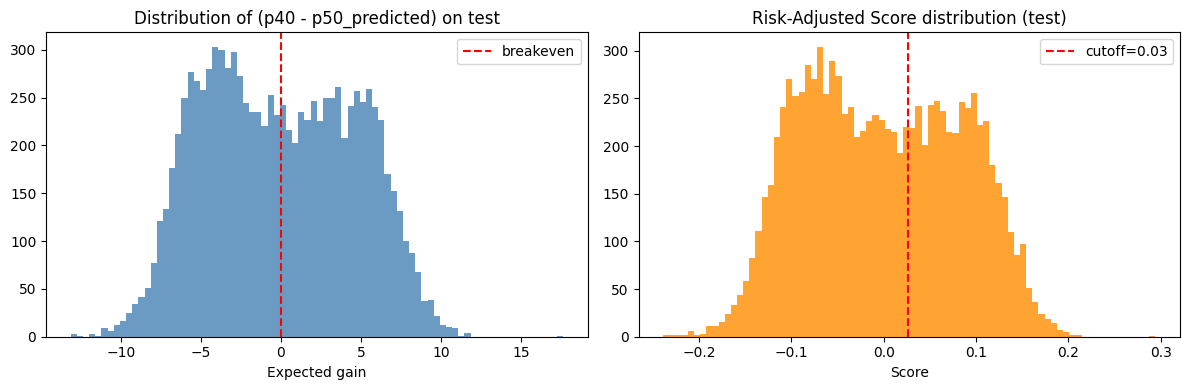


Median expected gain (all test): -0.27
Median expected gain (sell=1):   4.64


In [16]:
# --- Diagnostics ---
expected_gain_test = p40_test - test_p50_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(expected_gain_test, bins=80, color='steelblue', alpha=0.8)
axes[0].axvline(0, color='red', ls='--', lw=1.5, label='breakeven')
axes[0].set_title('Distribution of (p40 - p50_predicted) on test')
axes[0].set_xlabel('Expected gain')
axes[0].legend()

axes[1].hist(scores_test, bins=80, color='darkorange', alpha=0.8)
cutoff = score_series_test.nlargest(MAX_SELL).min()
axes[1].axvline(cutoff, color='red', ls='--', lw=1.5, label=f'cutoff={cutoff:.2f}')
axes[1].set_title('Risk-Adjusted Score distribution (test)')
axes[1].set_xlabel('Score')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\nMedian expected gain (all test): {np.median(expected_gain_test):.2f}')
print(f'Median expected gain (sell=1):   {np.median(expected_gain_test[sell_test.values == 1]):.2f}')

In [17]:
# Save submission
submission = pd.DataFrame({'ID': test.index, 'sell': sell_test.values})
submission.to_csv('submission.csv', index=False)

print('submission.csv saved')
print(submission.head(10))
print(f'\nSell counts: {submission["sell"].value_counts().to_dict()}')

submission.csv saved
   ID  sell
0   0     0
1   1     0
2   2     0
3   3     0
4   4     0
5   5     0
6   6     1
7   7     0
8   8     1
9   9     0

Sell counts: {0: 6000, 1: 4000}
